<a href="https://colab.research.google.com/github/ZuckermanLab/CodingClass2026/blob/main/Part2_Kolluri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration with CPTAC: Visualizing Cancer Data

## Recap and overview

So far you've learned about the basics of Python: variables, loops, functions, and how to work with data using pandas. Now, we'll look at what happens when a dataset is not just a few numbers, but hundreds of thousands of measurements, and the tools scientists use to make sense of that scale.

This notebook uses real biomedical data from the Clinical Proteomic Tumor Analysis Consortium (CPTAC), which measures gene activity in cancer patients.

We will cover three main ideas:

1. **Data visualization**: turning tables of numbers into pictures we can actually understand.
2. **Correlations**: figuring out whether two measurements are related to each other.
3. **Dimensionality reduction (PCA)**: simplifying data that has thousands of columns down to just a few, without losing the important patterns.

![alt text](https://www.cancerimagingarchive.net/wp-content/uploads/2019/12/CPTAC-Screenshot-1536x960.png)

### Visualizations we will explore

* **Heatmaps**: to see patterns across many variables and samples at once.
* **Bar plots**: to compare quantities across different categories.
* **Histograms**: to see how one variable is distributed across all patients.
* **Scatter plots**: to see the relationship between two variables.
* **Contour plots (density)**: to see where points are most concentrated on a scatter plot.

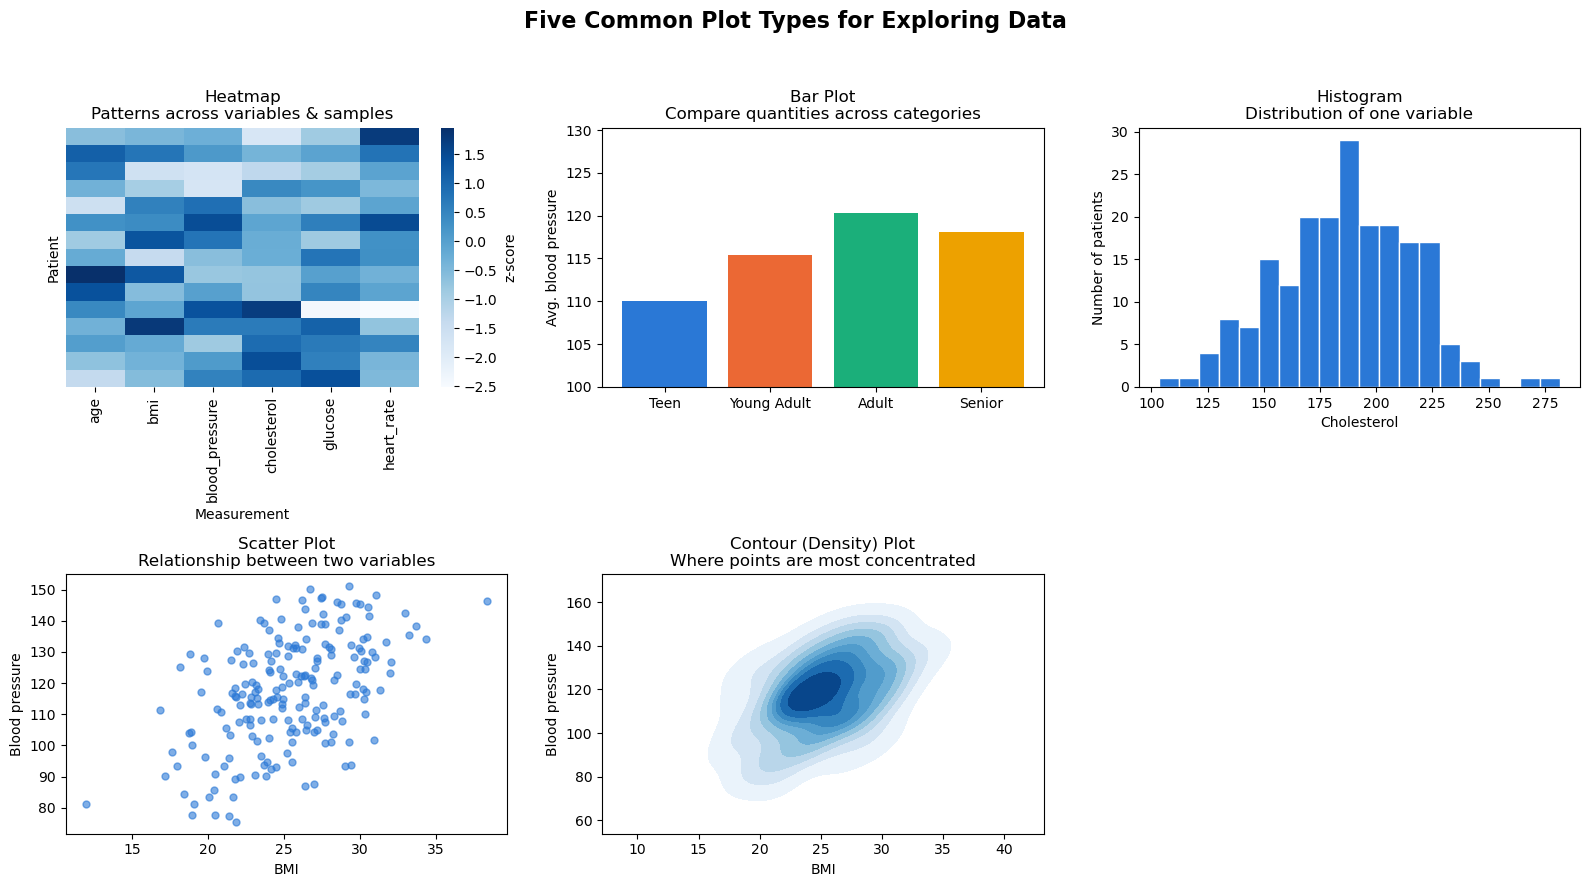

In [ ]:
# Setup: install the CPTAC library and load the packages we'll use
!pip install cptac

import cptac                     # Cancer Proteogenomic Analysis Consortium loader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Introduction to CPTAC data

The `cptac` library gives us access to rich data from real cancer patients, collected across many types of cancer. This includes measurements of gene activity, protein levels, and more.

Let's start by seeing what cancer types and data sources are available.

![alt text](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fcdn.kastatic.org%2Fka-perseus-images%2F2b597889d05bc601803a3b4d9ec5ccd5e7b8d3af.png&f=1&nofb=1&ipt=6fdb46fa8b16afdccd6b7e2091bb20be587d3184d62b07f167d79c471c8e4740)

In [ ]:
# what is in the cptac dataset?
cptac.get_source_options()

In [ ]:
# what do the cancer abbreviations stand for?
cptac.get_cancer_info()

In [ ]:
# If we focused on a single cancer type, what data can be collected?
bc = cptac.Brca() # for breast cancer...
bc.list_data_sources()

In [ ]:
# getting help from the package itself
help(bc) # <-- we've stored breast cancer data as bc ("bc = cptac.Brca()")

### Understanding transcriptomics data

Let's first load Breast Cancer (BRCA) data and specifically look at `transcriptomics` from the Broad Institute. Transcriptomics data measures the level of gene expression, indicating how active different genes are in a sample. High expression might mean a gene is very active, while low expression might mean it's less active.

This data is stored in a `pandas.DataFrame`, which is like a powerful spreadsheet in Python, perfect for organizing and analyzing tabular data. Each row represents a patient, and each column represents a specific gene transcript. Many genes have multiple transcripts, hence the multi-level column names like `('A1BG', 'ENST...')`.

In [ ]:
# bc = cptac.Brca() <-- we just used this command
bc.get_transcriptomics('bcm') # what is this doing? # hint: look at table (try switching institution)

In [ ]:
transcriptomics = bc.get_transcriptomics('broad')

In [ ]:
print(type(transcriptomics))

In [ ]:
transcriptomics["A1CF"].head() # try adding a value in the parenthesis and replacing head with tail

In [ ]:
print(np.array(transcriptomics.columns)[:30])

---
### Data visualization: heatmaps

Heatmaps are powerful tools for visualizing patterns in data tables. Each cell in the table is colored according to its value, allowing you to quickly spot areas of high or low activity. In our case, we're looking at the expression levels of several gene transcripts across different patients.

Below, we'll create a heatmap for the first 10 patients and a few selected gene transcripts. This helps us see at a glance which genes are highly expressed (brighter colors) and which are less expressed (darker colors) in different patients.

In [ ]:
# choose different data categories
# make note that heatmaps are not perfect plots, comment out specific cols and see how color bar changes
# 1: grab the first 10 patient IDs
patient_ids = transcriptomics.index[:10]          # rows 0-9

# 2: the (gene, transcript_ID) pairs we want
cols = [
    ("A1BG",     "ENST00000596924.1"),
    ("A1BG-AS1", "ENST00000593960.5"),
    ("A2M",      "ENST00000318602.12"),
    ("ZZEF1",    "ENST00000573536.1")
]

# 3: build a 10x5 NumPy array of expression values
data = np.array(
    [[transcriptomics.loc[pid, col] for col in cols]  # one row per patient
     for pid in patient_ids],
    dtype=float
)

# 4: draw the heat-map
fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(data, cmap="viridis", aspect="auto")

# x-axis: gene + transcript labels
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels([f"{g}\n{t}" for g, t in cols],
                   rotation=45, ha="right", fontsize=8)

# y-axis: patient IDs
ax.set_yticks(np.arange(len(patient_ids)))
ax.set_yticklabels(patient_ids)

# colour bar
cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Expression level")

plt.title("Transcript expression for the first 10 patients", pad=20)
plt.tight_layout()
plt.show()

#### Bonus: heatmaps with a log-based color scale

Sometimes the values we want to plot span a huge range, some very small and some very large. On a normal color scale, the small values all look about the same (too dark or too light to tell apart), because the scale is stretched to fit the huge values too.

One fix is a logarithmic scale, similar to how the Richter scale for earthquakes works: each step represents a much bigger jump than the last, so both small and large values stay visible. The plot below uses a version of this called `SymLogNorm`, which handles positive and negative numbers around zero.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# 1: grab the first 10 patient IDs
patient_ids = transcriptomics.index[:10]          # rows 0-9

# 2: the (gene, transcript_ID) pairs we want
# NOTE: Comment out one or more tuples below to see how the colorbar rescales.
cols = [
    ("A1BG",     "ENST00000596924.1"),
    ("A1BG-AS1", "ENST00000593960.5"),
    ("A2M",      "ENST00000318602.12"),
    ("ZZEF1",    "ENST00000573536.1"),
]

# 3: build a (patients x transcripts) array
data = np.array(
    [[transcriptomics.loc[pid, col] for col in cols]
     for pid in patient_ids],
    dtype=float
)

# 3a: decide normalization parameters
vmin = np.nanmin(data)
vmax = np.nanmax(data)

# SymLogNorm needs a linthresh > 0 (half-width of the linear region around 0)
# Choose something small relative to your data spread.
# A heuristic: 1% of the max absolute value (but at least a tiny floor).
absmax = max(abs(vmin), abs(vmax))
linthresh = max(absmax * 0.01, 1e-6)

# You can optionally choose linscale (size of linear region in color steps)
norm = SymLogNorm(linthresh=linthresh, linscale=1.0, vmin=vmin, vmax=vmax)

# 4: plot
fig, ax = plt.subplots(figsize=(6, 3.8))
im = ax.imshow(data, cmap="viridis", aspect="auto", norm=norm)

# x-axis labels (gene\ntranscript)
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels([f"{g}\n{t}" for g, t in cols],
                   rotation=45, ha="right", fontsize=8)

# y-axis labels (patient IDs)
ax.set_yticks(np.arange(len(patient_ids)))
ax.set_yticklabels(patient_ids)

# color bar (log-like, symmetric)
cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Expression level (sym log scale)")
cbar.ax.set_ylabel("Expression level (sym log scale)", rotation=90, labelpad=10)

plt.title("Transcript expression (first 10 patients), SymLog color scale", pad=20)
plt.tight_layout()
plt.show()

print(f"SymLogNorm settings: vmin={vmin:.3g}, vmax={vmax:.3g}, linthresh={linthresh:.3g}")

---
### Data visualization: bar plots

Bar plots are excellent for comparing discrete categories. They use rectangular bars to show the value associated with each category. For example, if we want to compare the expression level of a specific gene transcript across a few different patients, a bar plot can quickly highlight who has higher or lower expression.

Below, we'll create a bar plot for the 'A1BG' gene transcript for the first 5 patients.

In [ ]:
# Let's select a specific gene transcript, for example, 'A1BG' (Ensembl ID 'ENST00000596924.1').
# This line extracts the data for this specific transcript across all patients.
gene_of_interest = ("A1BG", "ENST00000596924.1")
alb1_data = transcriptomics.loc[:, gene_of_interest]

# Display the data for the first 5 patients for this transcript
display(alb1_data.head())

In [ ]:
# To create a bar plot for the first 5 patients, we need their IDs and their expression values.
# We'll use the 'alb1_data' Series we just created.

# Get the first 5 patient IDs from the index
patient_ids_first5 = alb1_data.index[:5]

# Get the expression values for these first 5 patients
values_first5 = alb1_data.head(5)

# Create the bar plot
plt.figure(figsize=(8, 5))
values_first5.plot(kind="bar", color='skyblue')
plt.title(f"Expression of {gene_of_interest[0]} ({gene_of_interest[1]}) for First 5 Patients")
plt.xlabel("Patient ID")
plt.ylabel("Expression Level")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---
### Data visualization: histograms

A histogram is a graphical representation of the distribution of numerical data. It groups data into 'bins' (ranges) and shows how many data points fall into each bin. This helps us understand the spread, central tendency, and shape of the data for a single variable.

For example, we can use a histogram to see how the expression levels of a specific gene transcript are distributed across *all* patients. Are most patients showing low expression? Or is there a wide range of expression levels?

In [ ]:
# We will create a histogram for the 'A1BG' transcript across ALL patients to see its distribution.
# Ensure 'alb1_data' is defined from earlier steps (it should be).

# Remove any missing values (NaN) before plotting the histogram
values_for_hist = alb1_data.dropna().to_numpy(dtype=float)

plt.figure(figsize=(6,4))
# 'bins="auto"' lets matplotlib choose a good number of bins automatically
plt.hist(values_for_hist, bins="auto", edgecolor="black")
plt.xlabel("Expression Level")
plt.ylabel("Number of Samples (Patients)")
plt.title(f"Distribution of {gene_of_interest[0]} ({gene_of_interest[1]}) Expression")
plt.tight_layout()
plt.show()

---
### Correlations: exploring relationships with scatter plots

Correlations describe how two variables move together. If two variables tend to increase or decrease together, they are positively correlated. If one increases while the other decreases, they are negatively correlated. If there's no clear pattern, they might be uncorrelated.

A **scatter plot** is the most common way to visualize the relationship between two numerical variables. Each point on the plot represents a single patient, with its x-coordinate showing the expression of one gene and its y-coordinate showing the expression of another. By looking at the pattern of points, we can infer if a correlation exists.

In [ ]:
# Let's explore the correlation between two different gene transcripts using a scatter plot.
# We will use 'A1BG' and 'ZZEF1' as examples.

# 1. Grab each transcript column (MultiIndex style: (gene, transcript_ID))
x_gene = ("A1BG",      "ENST00000596924.1")
y_gene = ("ZZEF1", "ENST00000573536.1")

x = transcriptomics.loc[:, x_gene]
y = transcriptomics.loc[:, y_gene]

# 2. Combine them into a single DataFrame and keep only samples that have values for BOTH transcripts.
# This ensures that each point in the scatter plot represents a patient with valid data for both genes.
xy = pd.concat([x, y], axis=1, keys=[x_gene[0], y_gene[0]]).dropna()

# 3. Create the scatter plot
plt.figure(figsize=(7,5))
plt.scatter(xy[x_gene[0]], xy[y_gene[0]], alpha=0.7)
plt.xlabel(f"{x_gene[0]} expression")
plt.ylabel(f"{y_gene[0]} expression")
plt.title("Transcript Expression Scatter Plot")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Putting a number on correlation

The scatter plot gives us a visual sense of the relationship, but we can also describe it with a single number called the **correlation coefficient**. It ranges from -1 to 1:

* Close to **1**: a strong positive relationship (as one goes up, so does the other).
* Close to **-1**: a strong negative relationship (as one goes up, the other goes down).
* Close to **0**: little to no relationship.

Pandas can calculate this for us directly.

In [ ]:
correlation = xy[x_gene[0]].squeeze().corr(xy[y_gene[0]].squeeze())
print(f"Correlation between {x_gene[0]} and {y_gene[0]}: {correlation:.2f}")

#### Scatter plot with marginal histograms

While a scatter plot shows the relationship between two variables, sometimes it's also useful to see the individual distributions of each variable. We can combine a scatter plot with **marginal histograms**, which are histograms plotted along the axes of the scatter plot.

This setup allows us to simultaneously see:
1.  The relationship between the two gene transcripts (in the central scatter plot).
2.  The distribution of the first gene transcript (in the top histogram).
3.  The distribution of the second gene transcript (in the right-side histogram).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 1. Grab each transcript column (MultiIndex style: (gene, transcript_ID))
x = transcriptomics.loc[:, ("A1BG",     "ENST00000596924.1")]
y = transcriptomics.loc[:, ("ZZEF1", "ENST00000573536.1")]

# 2. Keep only the samples that have a value for BOTH transcripts
xy = pd.concat([x, y], axis=1, keys=["A1BG", "ZZEF1"]).dropna()

# 3. Figure layout: scatter in the middle, histograms on top & right
fig = plt.figure(figsize=(6, 6))
gs  = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                        wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histx   = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# 4. Scatter plot
ax_scatter.scatter(xy["A1BG"], xy["ZZEF1"], alpha=0.7)
ax_scatter.set_xlabel("A1BG expression")
ax_scatter.set_ylabel("ZZEF1 expression")

# 5. Histograms (marginals)
ax_histx.hist(xy["A1BG"], bins="auto", edgecolor="black")
ax_histy.hist(xy["ZZEF1"], bins="auto", orientation="horizontal",
              edgecolor="black")

# tidy up tick labels
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

fig.suptitle("Transcript-level expression correlation")
plt.tight_layout()
plt.show()

#### Try it yourself: explore other gene pairs

The tool below lets you pick any two gene transcripts from the dropdown menus and instantly see their scatter plot, marginal histograms, and correlation coefficient. Try a few different pairs. Can you find two genes that look strongly correlated? What about two that look unrelated?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output

# Calculate variance for each transcriptomics column and select top 20 most variable genes
variances = {}
for col in transcriptomics.columns:
    series = transcriptomics.loc[:, col].dropna()
    # Only consider series with more than one unique value to calculate meaningful variance
    if not series.empty and series.nunique() > 1:
        variances[col] = series.var()
    else:
        variances[col] = 0.0 # Assign 0 variance for non-varying or empty series

# Sort by variance in descending order and get top 20
sorted_genes = sorted(variances.items(), key=lambda item: item[1], reverse=True)
# Filter out genes with zero variance before taking the top 20
top_genes_cols = [col_tuple for col_tuple, var in sorted_genes if var > 0][:20]

# Fallback if fewer than 2 variable genes are found (highly unlikely for this dataset)
# This ensures the dropdowns can be initialized without error.
if len(top_genes_cols) < 2:
    print("Warning: Fewer than 2 variable genes found. Using the first available columns.")
    # Take the first two columns directly from transcriptomics.columns as a fallback
    if len(transcriptomics.columns) >= 2:
        top_genes_cols = list(transcriptomics.columns[:2])
    else:
        # If even fewer than 2 total columns, this setup will likely fail downstream.
        # This is an edge case unlikely with the CPTAC data.
        print("Error: Not enough columns in transcriptomics for dropdowns.")
        top_genes_cols = [] # Or handle error more robustly

col_options = []
for col in top_genes_cols:
    # col is a 3-tuple (Gene_Name, Transcript_ID, Database_ID)
    # We show gene | transcriptID to the user
    label = f"{col[0]} | {col[1]}"
    col_options.append((label, col)) # (what user sees, what we use for selection)

# Initialize dropdowns with the selected top genes
x_dropdown = widgets.Dropdown(options=col_options,
                              value=col_options[0][1] if col_options else None, description="X:")
y_dropdown = widgets.Dropdown(options=col_options,
                              value=col_options[1][1] if len(col_options) > 1 else (col_options[0][1] if col_options else None), description="Y:")

out = widgets.Output()

def series_from_column(col_tuple):
    """Return a 1-D Series for a given MultiIndex column key."""
    # transcriptomics.loc[:, col_tuple] will return a Series directly if col_tuple is a full 3-tuple
    s = transcriptomics.loc[:, col_tuple]
    return s

def update_plot(change=None):
    with out:
        clear_output(wait=True)

        # grab chosen transcripts from dropdowns
        x_pair, y_pair = x_dropdown.value, y_dropdown.value

        if x_pair is None or y_pair is None:
            print("Please select two genes from the dropdowns.")
            return

        x = series_from_column(x_pair)
        y = series_from_column(y_pair)

        # paired, drop missing values
        xy = pd.concat([x, y], axis=1, keys=["X", "Y"]).dropna()

        if xy.empty:
            print(f"No overlapping patient data for {x_pair[0]} and {y_pair[0]} to plot.")
            return

        # figure layout
        fig = plt.figure(figsize=(6, 6))
        gs  = gridspec.GridSpec(2, 2, width_ratios=[4, 1],
                                height_ratios=[1, 4],
                                wspace=0.05, hspace=0.05)
        ax_s  = fig.add_subplot(gs[1, 0])
        ax_hx = fig.add_subplot(gs[0, 0], sharex=ax_s)
        ax_hy = fig.add_subplot(gs[1, 1], sharey=ax_s)

        # scatter
        ax_s.scatter(xy["X"], xy["Y"], alpha=0.7)
        ax_s.set_xlabel(f"{x_pair[0]} ({x_pair[1]}) expression")
        ax_s.set_ylabel(f"{y_pair[0]} ({y_pair[1]}) expression")

        # marginals
        ax_hx.hist(xy["X"], bins="auto", edgecolor="black")
        ax_hy.hist(xy["Y"], bins="auto", orientation="horizontal",
                   edgecolor="black")
        ax_hx.tick_params(axis="x", labelbottom=False)
        ax_hy.tick_params(axis="y", labelleft=False)

        correlation = xy["X"].corr(xy["Y"])
        fig.suptitle(f"Transcript-level expression correlation (r = {correlation:.2f})")
        plt.tight_layout()
        plt.show()

# initial draw and callbacks
update_plot()
x_dropdown.observe(update_plot, names="value")
y_dropdown.observe(update_plot, names="value")

# Display controls and output
display(widgets.HBox([x_dropdown, y_dropdown]))
display(out)

---
### Dimensionality reduction: Principal Component Analysis (PCA)

Imagine trying to compare patients using thousands of different gene measurements at once. That is far too much information to plot or think about directly. **Dimensionality reduction** is a way of shrinking that huge table down to just a few new combined variables, while keeping as much of the important information as possible.

**Principal Component Analysis (PCA)** is the most common way to do this. It looks for new variables, called **principal components**, that are combinations of the original genes. The first principal component (PC1) captures the biggest pattern of variation across patients, PC2 captures the next biggest pattern, and so on.

Because we usually only need the first two or three principal components to see the main patterns, PCA lets us plot data that originally had thousands of columns as a simple 2D or 3D scatter plot.


In [ ]:
# if you're interested, this is a way to display a webpage inside of a python notebook!
# I've done some cropping of this "iframe" to remove some ads

from IPython.display import HTML

HTML("""
<div style="
    width: 100%;
    height: 2500px; /* Visible viewport height in Colab */
    overflow: hidden;
    position: relative;
    border: 1px solid #e0e0e0;
    border-radius: 8px;
">
  <iframe
    src="https://numiqo.com/lab/pca"
    scrolling="no"
    style="
        width: 100%;
        height: 2950px; /* Sets max rendering depth, cutting off the ad at bottom */
        border: 0;
        position: absolute;
        top: -425px; /* Crops out top site navbar */
        overflow: hidden;
    "
  ></iframe>
</div>
""")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# We'll use a subset of transcripts for PCA to make it easier to visualize and interpret.
# These columns represent selected gene transcripts.
cols = [
    ("A1BG",     "ENST00000596924.1"),
    ("A1BG-AS1", "ENST00000593960.5"),
    ("A2M",      "ENST00000318602.12"),
    ("ZZEF1",    "ENST00000573536.1"),
]

# Helper function to reliably get a Series from a MultiIndex column
def get_series(col_key):
    s = transcriptomics.loc[:, col_key]
    # If the selection results in a DataFrame (can happen with certain MultiIndex structures),
    # take the first (and usually only) column.
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    return s

# Build a DataFrame with selected transcripts, dropping patients with any missing data for these.
# This ensures PCA is performed on a complete dataset for the chosen features.
df_pca_features = pd.DataFrame({
    f"{g}|{t}": get_series((g, t)) for g, t in cols
}).dropna()

# 1. Standardize features (mean 0, standard deviation 1).
# This is crucial for PCA because it ensures that genes with larger expression values
# don't disproportionately influence the principal components.
X_standardized = (df_pca_features - df_pca_features.mean(axis=0)) / df_pca_features.std(axis=0, ddof=0)

# 2. Perform PCA
# PCA will transform our original gene expression data into a new set of variables (Principal Components).
pca = PCA() # Initialize PCA model
scores = pca.fit_transform(X_standardized)   # Fit PCA and transform the data

# 3. Explained variance ratio
# This tells us how much of the total variability in the data each principal component captures.
expl_var = pca.explained_variance_ratio_

# 4. Put the first two Principal Components (PC1 and PC2) into a DataFrame for easy plotting.
# These are often the most informative components.
scores_df = pd.DataFrame(scores[:, :2], index=df_pca_features.index, columns=["PC1", "PC2"])

# Optional: print summaries for deeper understanding
print("Explained variance ratio per PC:")
for i, r in enumerate(expl_var, start=1):
    print(f"  PC{i}: {r:.2%}")
print("\nStandardized data (first 5 rows):")
display(X_standardized.head())
print("\nPC1/PC2 scores (first 5 rows):")
display(scores_df.head())

# 5. Scatter plot of samples in PC1 vs PC2
# This visualization shows how patients cluster based on their expression profiles in the reduced space.
plt.figure(figsize=(7, 6))
plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.8)
plt.xlabel(f"PC1 ({expl_var[0]:.1%} variance explained)")
plt.ylabel(f"PC2 ({expl_var[1]:.1%} variance explained)")
plt.title("PCA of Selected Transcripts (Patients in PC1 vs PC2)")
plt.axhline(0, color="gray", linewidth=0.5, linestyle='--')
plt.axvline(0, color="gray", linewidth=0.5, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Scree plot: visualizing the variance explained by each principal component.
# This plot helps determine how many principal components are important.
plt.figure(figsize=(6,4))
plt.bar(range(1, len(expl_var)+1), expl_var, color='lightcoral')
plt.xlabel("Principal Component Number")
plt.ylabel("Variance Explained Ratio")
plt.title("Scree Plot: Variance Explained by Each Principal Component")
plt.xticks(range(1, len(expl_var)+1)) # Ensure x-ticks for each PC
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Visualizing PCA with density contour plots

After running PCA, we often plot patients using their first two principal components (PC1 and PC2) to see how they are spread out. A plain scatter plot shows individual points, but when there are a lot of points, it can be hard to tell where they are most concentrated.

**Density contour plots** solve this by drawing contour lines around areas where points are packed closely together, similar to how a topographic map uses contour lines to show elevation instead of individual measurements. The closer together the lines, the more crowded that region is.

![alt text](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.thelanddevelopmentsite.com%2Fwp-content%2Fuploads%2F2020%2F02%2FTopographic-Map.jpg&f=1&nofb=1&ipt=77d7b847d46f718bf3cf0cc7fc66d64985d04a2eafd2ee636e9f511dc5b74e30)

In [ ]:
# Contour (KDE) plot of samples in PC1 vs PC2
from scipy.stats import gaussian_kde  # SciPy provides a kernel-density estimator

# 1. Pull the x (PC1) and y (PC2) coordinates as plain NumPy arrays
x_vals = scores_df["PC1"].to_numpy()
y_vals = scores_df["PC2"].to_numpy()

# 2. Fit a 2-D Gaussian KDE to the points
kde = gaussian_kde(np.vstack([x_vals, y_vals]))

# 3. Build a regular grid that spans the data range
xmin, xmax = x_vals.min(), x_vals.max()
ymin, ymax = y_vals.min(), y_vals.max()
xi = np.linspace(xmin, xmax, 150)
yi = np.linspace(ymin, ymax, 150)
X, Y = np.meshgrid(xi, yi)

# 4. Evaluate the KDE on the grid, reshape to 2-D
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# 5. Plot: filled contours + contour lines
plt.figure(figsize=(6, 5))
cont = plt.contourf(X, Y, Z, levels=15, cmap="Blues")         # filled stripes
plt.contour( X, Y, Z, levels=15, colors="black", linewidths=0.3)  # thin lines

# 6. (Optional) overlay the original points for reference
plt.scatter(x_vals, y_vals, s=20, color="red", alpha=0.6, label="patients")
plt.legend(loc="upper right", fontsize=8)

# 7. Labels with variance explained
plt.xlabel(f"PC1 ({expl_var[0]:.1%} variance)")
plt.ylabel(f"PC2 ({expl_var[1]:.1%} variance)")
plt.title("PCA density contour: all patients")
plt.colorbar(cont, label="Kernel density")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

#### Marginal density plots for principal components

Just as we used marginal histograms with scatter plots, we can also look at the individual distributions of our principal components. **Marginal density plots** for PC1 and PC2 show how the scores for each principal component are distributed across all patients.

This helps us understand:
*   The range of values each PC takes.
*   If scores are concentrated in certain areas (e.g., bimodal distribution).
*   How much variability each PC accounts for, which is also reflected in the 'variance explained' percentage.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Assume you already have: scores (n_samples x n_components), expl_var (variance ratios)
# If not, be sure you've run PCA and have those variables defined.

pc1 = scores[:, 0]
pc2 = scores[:, 1]

# Build grids over each PC range
grid1 = np.linspace(pc1.min(), pc1.max(), 400)
grid2 = np.linspace(pc2.min(), pc2.max(), 400)

# KDE (Gaussian) fits
kde1 = gaussian_kde(pc1)
kde2 = gaussian_kde(pc2)

dens1 = kde1(grid1)
dens2 = kde2(grid2)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# PC1
axes[0].plot(grid1, dens1)
axes[0].fill_between(grid1, dens1, alpha=0.4)
axes[0].set_title(f"PC1 Density (var: {expl_var[0]:.1%})")
axes[0].set_xlabel("PC1 score")
axes[0].set_ylabel("Density")

# PC2
axes[1].plot(grid2, dens2)
axes[1].fill_between(grid2, dens2, alpha=0.4)
axes[1].set_title(f"PC2 Density (var: {expl_var[1]:.1%})")
axes[1].set_xlabel("PC2 score")

plt.tight_layout()
plt.show()

### Wrap-up

In this notebook we used real cancer patient data to practice three big ideas in data analysis:

* **Visualization** turns huge tables of numbers into pictures (heatmaps, bar plots, histograms, scatter plots) that our brains can actually interpret.
* **Correlation** gives us both a visual and a numeric way to describe how two variables relate to each other.
* **Dimensionality reduction (PCA)** lets us shrink data with thousands of columns down to a handful of principal components, so we can still see the big patterns.

These same tools apply far beyond cancer genomics. They show up anywhere someone is trying to make sense of a large, messy dataset.